In [1]:
from src import clustering, graph_utils, plotting
import spatialdata as sd
import os 
from napari_spatialdata import Interactive

c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
dirs = os.listdir("C://Users//laure//Desktop//github//sys_gen//zarr")

In [4]:
dirs

['human_bone_marrow_acute_lymphoid_leukemia',
 'human_brain_preview',
 'human_non_diseased_lung',
 'mouse_bone_formic_acid_decalcification',
 'mouse_brain_replicate_1',
 'mouse_colon']

In [4]:
sdata = sd.read_zarr("C://Users//laure//Desktop//github//sys_gen//zarr//" + dirs[4])
adata = sdata.tables["table"]

In [5]:
graph_utils.get_distances(adata, k=1, log=True)

In [6]:
results = clustering.fit_gmm(adata, distance_key="1_nn_distance", k_range=range(1,10))

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\subprocess.py", line 1601, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte
c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible a

Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9


Let's visualize the scores by number of components to see which is the optimal k to choose:

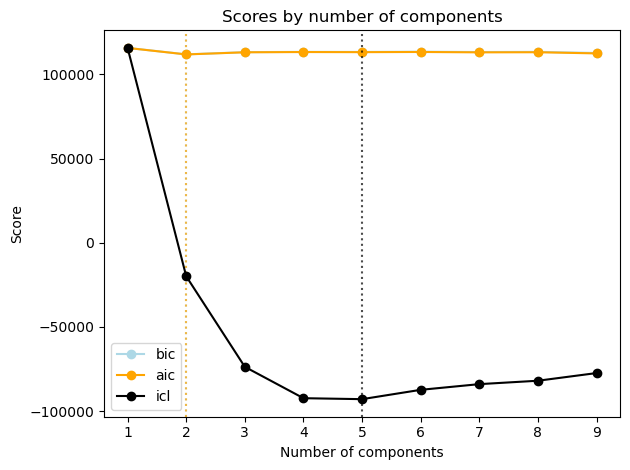

In [7]:
plotting.plot_scores(results)

BIC and AIC are almost identical which is why they overlap. Looking at ICL one can very well see a minimum. Let's pick the model with minimum ICL and continue with that.

In [7]:
best_model = clustering.choose_component(results, delta_bic_threshold=10.0)

Now we just assign the GMM labels to our cells, construct the neighbor graph and place seeds for watershed.

In [8]:
adata.obs["gmm_labels"] = best_model["labels"]
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category") 

By providing the gmm labels as library id, we construct neighbor graphs for each gmm domain separately. In the end we have one adjacency block matrix, each block representing a domain.

In [9]:
graph_utils.get_neighbors(adata, type="delaunay")

In [10]:
graph_utils.prune_graph(adata, "gmm_labels")

c:\Users\laure\Desktop\github\Adaptive-Niche\src\graph_utils.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_label = adata.obs[gmm_key][i]
c:\Users\laure\Desktop\github\Adaptive-Niche\src\graph_utils.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  keep = adata.obs[gmm_key][neigh] == row_label


In [11]:
graph_utils.set_seeds(adata, "1_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities")

Now we run a variety of clustering algorithms to see how they differ. Note that kmeans is applied on the distance values and dbscan is applied on the coordinates, while watershed and leiden make use of the adjacency matrix.

In [13]:
for flavor in ["watershed", "leiden", "kmeans", "dbscan"]:
    clustering.cluster_domains(adata, spatial_connectivity_key="spatial_connectivities_pruned", flavor=flavor, distances_key="1_nn_distance")

In [12]:
for flavor in ["watershed"]:
    clustering.watershed_by_descent(adata, distances_key="1_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities")

To finish off, we assign unique colors to our niche labels such that we can visualize it using napari-spatialdata.

In [13]:
plotting.assign_colors(sdata, "watershed_by_descent")

In [14]:
adata.obs["watershed_by_descent"].nunique()

76402

In [ ]:
Interactive(sdata)

2026-02-03 00:20:58.512 | WARNING  | napari_spatialdata._viewer:__init__:57 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


2026-02-03 00:21:02.808 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-02-03 00:21:03.056 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.


Plotting niche statistics

c:\Users\laure\Desktop\github\Adaptive-Niche\src\plotting.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  def assign_colors(sdata, column_key, seed=42):


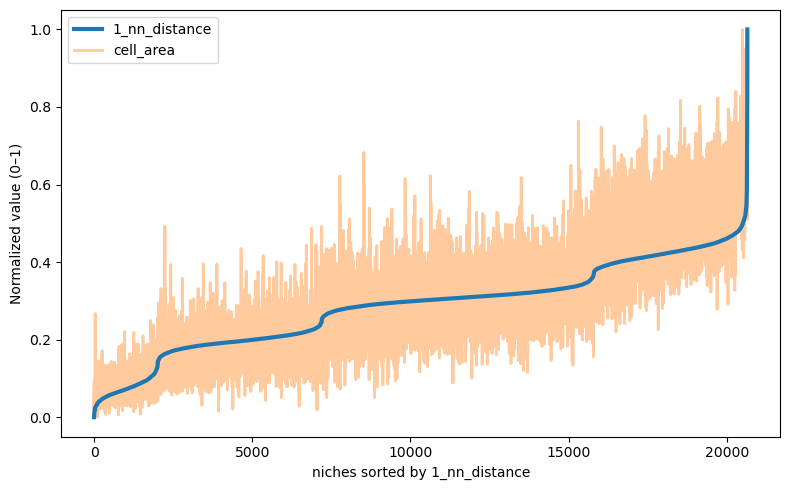

In [29]:
plotting.plot_niche_stats(sdata.tables["table"], col_keys=["1_nn_distance", "cell_area"], category_key="watershed_niches", sort_by="1_nn_distance")

c:\Users\laure\Desktop\github\Adaptive-Niche\src\plotting.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  def assign_colors(sdata, column_key, seed=42):
c:\Users\laure\Desktop\github\Adaptive-Niche\src\plotting.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Assign unique colors to each category in a given column.


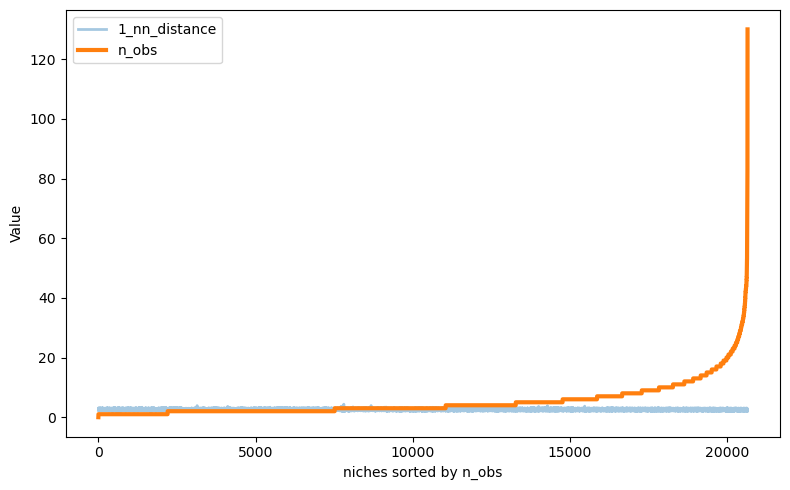

In [30]:
plotting.plot_niche_stats(sdata.tables["table"], col_keys=["1_nn_distance","n_obs"], category_key="watershed_niches", sort_by="n_obs", normalize=False)

In [23]:
adata = sdata.tables["table"][sdata.tables["table"].obs["watershed_niches"] == 0]

c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\anndata\_core\anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\anndata\_core\anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
C:\Users\laure\Desktop\github\squidpy_new\squidpy\src\squidpy\pl\_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


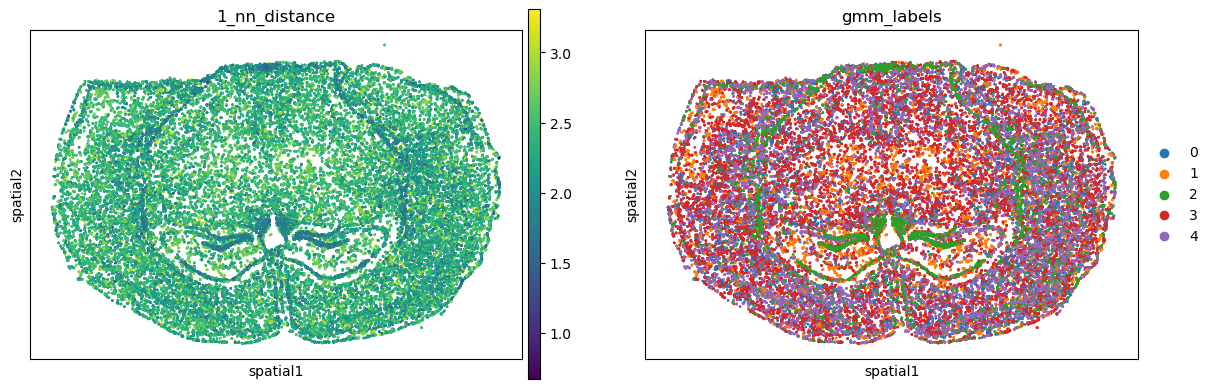

In [24]:
import squidpy as sq
sq.pl.spatial_scatter(adata, color=["1_nn_distance","gmm_labels"], shape=None)

In [25]:
sdata.tables["table"].obs.groupby("watershed_niches").size().reset_index(name="n_obs")

C:\Users\laure\AppData\Local\Temp\ipykernel_27852\3005171559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdata.tables["table"].obs.groupby("watershed_niches").size().reset_index(name="n_obs")


,watershed_niches,n_obs
0,0,52842
1,1,1
2,2,3
3,3,2
4,4,2
...,...,...
20644,20644,2
20645,20645,3
20646,20646,8
20647,20647,11
